In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Project_NLP/dataset_final.csv')
df.head()
display(df)

,text,label
0,Cán bộ công an tử vong vì tai nạn giao thông h...,1
1,Chủ tịch UBND TP HCM: Chọn 38 trung tâm giải q...,1
2,Dùng cần cẩu giải cứu 2 người đi xe máy rơi xu...,1
3,Khói bụi trắng bao trùm khu vực gần nhà máy th...,1
4,Công bố quy trình 5 bước bổ nhiệm công chức là...,1
...,...,...
46831,BRUSSELS (Reuters) - Các đồng minh NATO hôm th...,1
46832,"LONDON (Reuters) - LexisNexis, nhà cung cấp th...",1
46833,MINSK (Reuters) - Dưới bóng các nhà máy thời X...,1
46834,MOSCOW (Reuters) - Bộ trưởng Ngoại giao Vatica...,1


In [ ]:
from pathlib import Path
import math
import re
from collections import defaultdict
import numpy as np

In [ ]:
pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.3 MB/s eta 0:00:00


In [ ]:
import regex as re

from underthesea import word_tokenize
EMAIL = re.compile(r"([\w0-9_\.-]+)(@)([\d\w\.-]+)(\.)([\w\.]{2,6})")
URL = re.compile(r"https?:\/\/(?!.*:\/\/)\S+")
PHONE = re.compile(r"(09|01[2|6|8|9])+([0-9]{8})\b")
MENTION = re.compile(r"@.+?:")
NUMBER = re.compile(r"\d+.?\d*")
DATETIME = '\d{1,2}\s?[/-]\s?\d{1,2}\s?[/-]\s?\d{4}'

RE_HTML_TAG = re.compile(r'<[^>]+>')
RE_CLEAR_1 = re.compile("[^_<>\s\p{Latin}]")
RE_CLEAR_2 = re.compile("__+")
RE_CLEAR_3 = re.compile("\s+")



def replace_common_token(txt):
    txt = re.sub(EMAIL, ' ', txt)
    txt = re.sub(URL, ' ', txt)
    txt = re.sub(MENTION, ' ', txt)
    txt = re.sub(DATETIME, ' ', txt)
    txt = re.sub(NUMBER, ' ', txt)
    return txt


def remove_emoji(txt):
    txt = re.sub(':v', '', txt)
    txt = re.sub(':D', '', txt)
    txt = re.sub(':3', '', txt)
    txt = re.sub(':\(', '', txt)
    txt = re.sub(':\)', '', txt)
    return txt


def remove_html_tag(txt):
    return re.sub(RE_HTML_TAG, ' ', txt)

def preprocess(txt, tokenize=True):
    txt = remove_html_tag(txt)
    txt = re.sub('&.{3,4};', ' ', txt)

    txt = txt.lower()
    txt = replace_common_token(txt)
    txt = remove_emoji(txt)
    txt = re.sub(RE_CLEAR_1, ' ', txt)
    txt = re.sub(RE_CLEAR_2, ' ', txt)
    txt = re.sub(RE_CLEAR_3, ' ', txt)
    txt = txt.strip()
    if tokenize:
      txt = word_tokenize(txt)
    return " ".join(txt)

In [ ]:

listDocs = []
for doc in df['text']:
    listDocs.append(preprocess(str(doc)))

In [ ]:
print(df['label'].value_counts())

label
1    25408
0    21428
Name: count, dtype: int64


In [ ]:
#from transformers import AutoTokenizer
import torch
from tqdm import tqdm


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Giả sử df đã có:
# df = DataFrame có N dòng, cột cuối là nhãn

# Lấy cột nhãn từ df (giả sử là cột cuối)
labels = df.iloc[:, -1].values  # hoặc df[df.columns[-1]]

# Tạo DataFrame mới
df = pd.DataFrame({
    'text': listDocs,
    'label': labels
})

# df = pd.DataFrame(data)


In [ ]:
text_column = 'text'
label_column = 'label'

df[text_column] = df[text_column].fillna('')
sentences = df[text_column].tolist()
labels = df[label_column].values

tokenizer = Tokenizer(num_words=None, oov_token="<unk>")
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(sentences)

max_len = 128
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=42, stratify=labels)


In [ ]:
class FakeNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FakeNewsDataset(X_train, y_train)
test_dataset = FakeNewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, output_dim=1, dropout=0.5):
        super(BiLSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm1 = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm3 = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True, bidirectional=True)

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, output_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)                      # (batch, seq_len, embedding_dim)
        lstm_out1, _ = self.lstm1(embedded)               # (batch, seq_len, hidden_dim*2)
        lstm_out2, _ = self.lstm2(lstm_out1)              # (batch, seq_len, hidden_dim*2)
        lstm_out3, _ = self.lstm3(lstm_out2)              # (batch, seq_len, hidden_dim*2)

        # Attention cơ bản: trọng số theo thời gian
        attn_weights = torch.softmax(self.attention(lstm_out3), dim=1)   # (batch, seq_len, 1)
        context = torch.sum(attn_weights * lstm_out3, dim=1)             # (batch, hidden_dim*2)

        out = self.dropout(context)
        out = self.relu(self.bn1(self.fc1(out)))          # (batch, 128)
        out = self.relu(self.bn2(self.fc2(out)))          # (batch, 64)
        out = self.fc3(out)                               # (batch, 1)
        return self.sigmoid(out).squeeze()

In [ ]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(word_index) + 1
embedding_dim = 100
hidden_dim = 64
dropout = 0.5

model = BiLSTMClassifier(vocab_size, embedding_dim, hidden_dim, 1, dropout).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Huấn luyện mô hình
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss= {total_loss / len(train_loader):.4f}")


Epoch 1: Loss= 0.1689
Epoch 2: Loss= 0.0907
Epoch 3: Loss= 0.0689
Epoch 4: Loss= 0.0498
Epoch 5: Loss= 0.0363


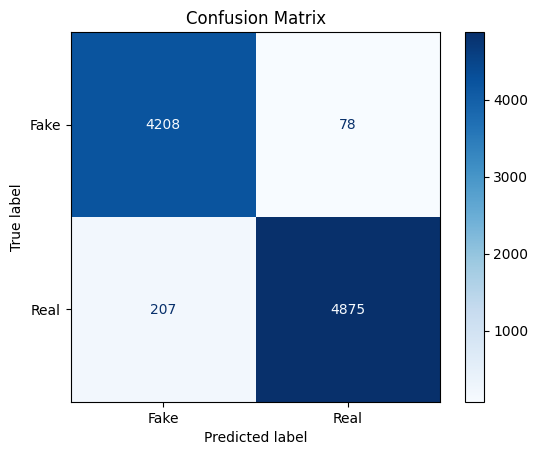


Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.98      0.97      4286
        Real       0.98      0.96      0.97      5082

    accuracy                           0.97      9368
   macro avg       0.97      0.97      0.97      9368
weighted avg       0.97      0.97      0.97      9368



In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = (outputs > 0.5).int().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

# Đánh giá
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Fake", "Real"]))

# ✅ Lưu thông tin cấu hình mô hình
  model_config = {
      'vocab_size': vocab_size,
      'embedding_dim': 300,
      'hidden_dim': 256,
      'output_dim': 1,
      'dropout': 0.5
  }

# ✅ Lưu checkpoint đầy đủ (gồm model, optimizer, epoch, cấu hình...)
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'model_config': model_config
}
torch.save(checkpoint, "Bi-LSTM_fakenews_full.pth")
save_path = "/content/drive/MyDrive/Bi-LSTM_fakenews_model.pth"
# model.save_pretrained(save_path)
# tokenizer.save_pretrained(save_path)
